# Week 7 Assignment

This week we are collecting some data from Reddit and doing some basic EDA on it. You should:

- create your Reddit account and API keys
- collect data from a subreddit of your choice
    - at a minimum, collect the posts from the subreddit; optionally collect comments on the posts
- save the data to a SQLite3 database
- perform some basic EDA on the data
    - create at least 2 plots
- write a short analysis at the end describing the process and results
- turn in the Jupyter Notebook and PDF printout or export to the week 7 dropbox

***Optional* advanced section**
- Practice SQL queries and select a subsection of the posts you collected
- Modify your code to collect data beyond the 1000 item limit
- Collect comments from the posts for analysis next week and do some EDA on the comments (e.g. who is the top commenter, which commenters have the most up and down votes or most controversial posts, etc)
- examine n-grams ([bigrams](https://stackoverflow.com/a/37651184/4549682), trigrams) or [collocations](https://www.geeksforgeeks.org/nlp-word-collocations/)

Note: There is no solution file for this week.

## Import Libraries

In [ ]:
import praw
import pandas as pd

import credentials

import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
import string
import time

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/ada/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Import the praw library and instantiate a praw.Reddit object using the provided credentials.

## Reddit API

In [3]:
reddit = praw.Reddit(client_id=credentials.client_id,
                     client_secret=credentials.client_secret,
                     user_agent=credentials.user_agent)

Specify the subreddit and choose a method to retrieve posts

## Collect Data

In [4]:
subreddit_name = "science" # "space"
co_subreddit = reddit.subreddit(subreddit_name).hot(limit=None)

In [5]:
reddit_data = {'title': [],
              'link': [],
              'author': [],
              'num_comments': [],
              'score': [],
              'text': []}

In [6]:
for post in list(co_subreddit):
    reddit_data['title'].append(post.title)
    reddit_data['link'].append(post.permalink)
    reddit_data['author'].append(post.author.name if post.author else None)
    reddit_data['num_comments'].append(post.num_comments)
    reddit_data['score'].append(post.score)
    reddit_data['text'].append(post.selftext)

In [7]:
post_df = pd.DataFrame(reddit_data)
post_df.head()

,title,link,author,num_comments,score,text
0,The Nobel Prize in Chemistry 2025: Awarded to ...,/r/science/comments/1o1cp2z/the_nobel_prize_in...,shiruken,10,332,The Nobel Prize in Chemistry 2025 was awarded ...
1,The Nobel Prize in Physics 2025: Awarded to Jo...,/r/science/comments/1o0hps8/the_nobel_prize_in...,shiruken,11,385,The Nobel Prize in Physics 2025 was awarded to...
2,The Democratic Party represents public opinion...,/r/science/comments/1o5mqea/the_democratic_par...,smurfyjenkins,170,1845,
3,Scientists have uncovered just how naked mole-...,/r/science/comments/1o5gk0m/scientists_have_un...,mvea,86,2544,
4,Men and women tend to approach sex with differ...,/r/science/comments/1o5j1vo/men_and_women_tend...,mvea,35,623,


## Load Data into Database

In [8]:
conn = sqlite3.connect('data/reddit.db')

In [9]:
post_df.to_sql('posts', conn, if_exists='replace', index=False)

conn.commit()
conn.close()

In [10]:
conn = sqlite3.connect('data/reddit.db')
co_df_check = pd.read_sql_query('SELECT * FROM posts;', conn)
# it's best to close the connection when finished
conn.close()
co_df_check.head()

,title,link,author,num_comments,score,text
0,The Nobel Prize in Chemistry 2025: Awarded to ...,/r/science/comments/1o1cp2z/the_nobel_prize_in...,shiruken,10,332,The Nobel Prize in Chemistry 2025 was awarded ...
1,The Nobel Prize in Physics 2025: Awarded to Jo...,/r/science/comments/1o0hps8/the_nobel_prize_in...,shiruken,11,385,The Nobel Prize in Physics 2025 was awarded to...
2,The Democratic Party represents public opinion...,/r/science/comments/1o5mqea/the_democratic_par...,smurfyjenkins,170,1845,
3,Scientists have uncovered just how naked mole-...,/r/science/comments/1o5gk0m/scientists_have_un...,mvea,86,2544,
4,Men and women tend to approach sex with differ...,/r/science/comments/1o5j1vo/men_and_women_tend...,mvea,35,623,


## Exploratory data analysis

In [11]:
print("Missing values per column:")
print(post_df.isnull().sum())

Missing values per column:
title           0
link            0
author          7
num_comments    0
score           0
text            0
dtype: int64


In [12]:
print("\nData types of each column:")
print(post_df.dtypes)


Data types of each column:
title           object
link            object
author          object
num_comments     int64
score            int64
text            object
dtype: object


<Axes: ylabel='Frequency'>

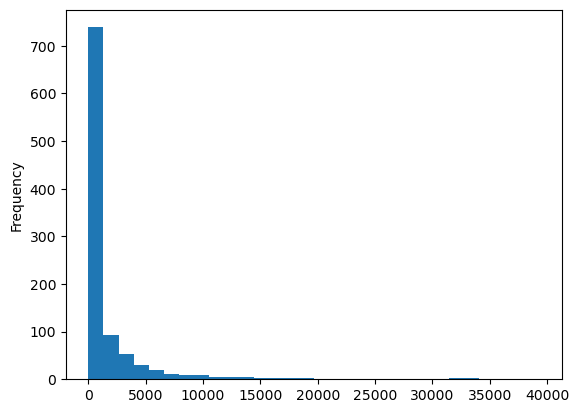

In [13]:
post_df['score'].plot.hist(bins=30)

Most values are clustered near zero, and very few reach the higher end (up to 40,000). That long tail suggests a small number of posts or users are driving massive engagement, while the majority stay quiet.

In [14]:
post_df[post_df['score'] > 15000]

,title,link,author,num_comments,score,text
24,Major IQ differences in identical twins linked...,/r/science/comments/1o4afve/major_iq_differenc...,mvea,839,22649,
57,A next-generation cancer vaccine has shown stu...,/r/science/comments/1o2v0nj/a_nextgeneration_c...,mvea,455,17897,
234,The human papillomavirus (HPV) vaccine is prot...,/r/science/comments/1nv52pu/the_human_papillom...,Wagamaga,860,32261,
265,Moral tone of right-wing Redditors varies by c...,/r/science/comments/1nu94z4/moral_tone_of_righ...,mvea,3144,31587,
308,Autism may be the price of human intelligence....,/r/science/comments/1nszxav/autism_may_be_the_...,mvea,1964,33408,
337,A new study suggests that scientists are leavi...,/r/science/comments/1nrti1x/a_new_study_sugges...,mvea,1077,35706,
384,“High-markup” hospitals are overwhelmingly for...,/r/science/comments/1npoqxf/highmarkup_hospita...,mvea,288,16619,
415,Patient deaths increased in emergency departme...,/r/science/comments/1no43s3/patient_deaths_inc...,mvea,442,27929,
458,Many Americans reject the scientific theory of...,/r/science/comments/1nmbck8/many_americans_rej...,mvea,1277,15356,
482,"1 in 3 young adults skip the dentist, putting ...",/r/science/comments/1nkmcc9/1_in_3_young_adult...,mvea,676,18377,


<Axes: >

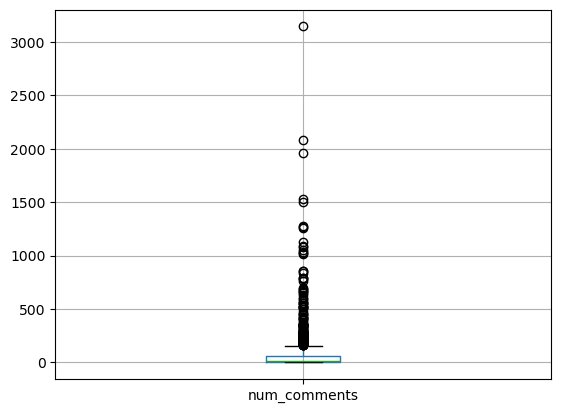

In [15]:
post_df.boxplot(column='num_comments')

Most posts receive a relatively low number of comments, but there are a few with very high engagement — over 3000 comments.

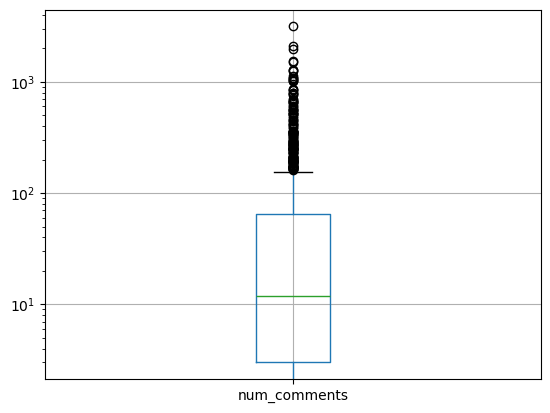

In [16]:
post_df.boxplot('num_comments')
plt.yscale('log')
plt.show()

By switching to plt.yscale('log'), we make the distribution easier to interpret. Instead of a few massive outliers dominating the plot, we can now see:
* The spread of typical posts (low to moderate comment counts)
* The relative position of high-comment posts without them overwhelming the scale

<Axes: xlabel='score', ylabel='num_comments'>

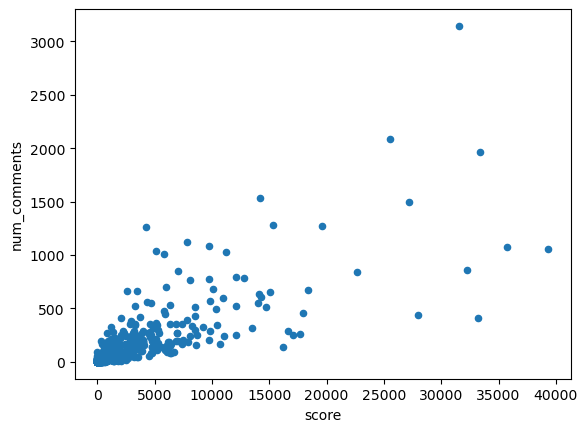

In [17]:
post_df.plot(kind='scatter', x='score', y='num_comments')

Most points cluster near the origin showing low scores and low comment counts are common. But there’s a faint upward trend: posts with higher scores tend to attract more comments.

<Axes: xlabel='author'>

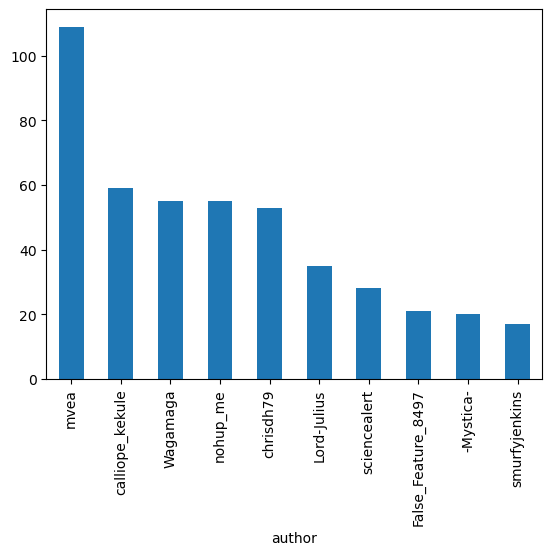

In [18]:
post_df['author'].value_counts()[:10].plot.bar()

from above we can see that `mvea` is the most common author

In [19]:
post_df[post_df['author'] == 'mvea'].head()

,title,link,author,num_comments,score,text
3,Scientists have uncovered just how naked mole-...,/r/science/comments/1o5gk0m/scientists_have_un...,mvea,86,2544,
4,Men and women tend to approach sex with differ...,/r/science/comments/1o5j1vo/men_and_women_tend...,mvea,35,623,
6,High youth death rates are an ‘emerging crisis...,/r/science/comments/1o54rtw/high_youth_death_r...,mvea,156,3209,
14,"Most people rarely use AI, and dark personalit...",/r/science/comments/1o4nn3i/most_people_rarely...,mvea,534,6336,
20,A first-of-its-kind study has found that recog...,/r/science/comments/1o4ldwn/a_firstofitskind_s...,mvea,188,3965,


## NLP

In [20]:
fd = nltk.FreqDist(' '.join(post_df['title']).split())
fd.most_common(10)

[('of', 743),
 ('and', 733),
 ('the', 706),
 ('in', 648),
 ('to', 633),
 ('a', 423),
 ('that', 285),
 ('with', 277),
 ('for', 234),
 ('study', 212)]

<Axes: xlabel='Samples', ylabel='Counts'>

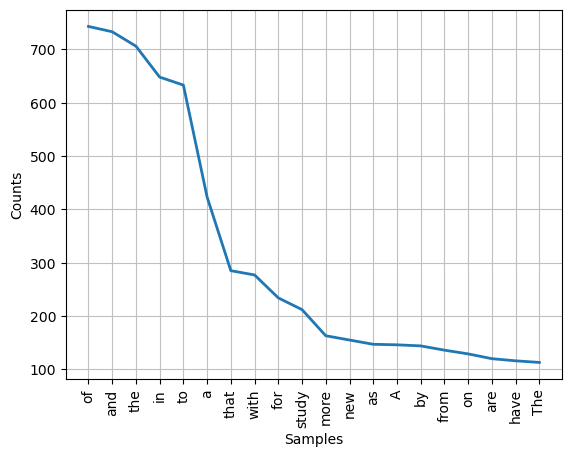

In [21]:
fd.plot(20)

In [22]:
stops = stopwords.words('english')
stops = set(stops) | set(['new', 'may', 'shows', 'likely', '|', 'finds', 'found'])

In [23]:
words = ' '.join(post_df['title']).lower().split()
cleaned_words = [word for word in words if word not in set(stops)]

In [24]:
cleaned_fd = nltk.FreqDist(cleaned_words)

In [25]:
cleaned_fd.most_common(20)

[('study', 267),
 ('researchers', 89),
 ('people', 81),
 ('research', 80),
 ('brain', 78),
 ('could', 70),
 ('scientists', 64),
 ('risk', 60),
 ('linked', 49),
 ('social', 48),
 ('higher', 47),
 ('health', 46),
 ('cells', 43),
 ('children', 41),
 ('cancer', 40),
 ('women', 37),
 ('first', 36),
 ('use', 36),
 ('human', 36),
 ('associated', 35)]

<Axes: xlabel='Samples', ylabel='Counts'>

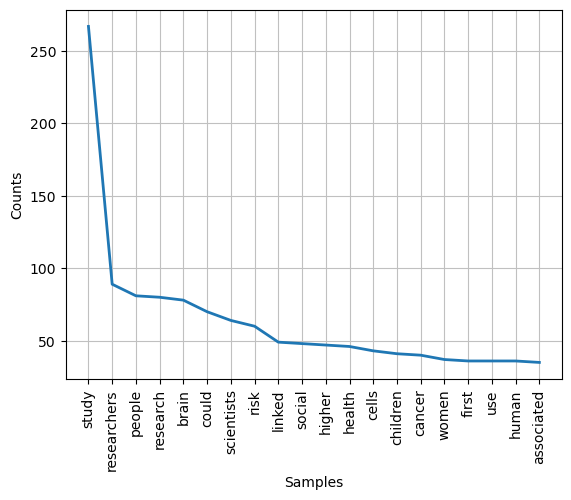

In [26]:
cleaned_fd.plot(20)

Words like “study,” “researchers” and “people” suggest that many comments are summarizing or reacting to scientific findings. This aligns well with r/science’s purpose — sharing peer-reviewed research and discussing implications.

## Analysis

We began by setting up Reddit API credentials and initializing a praw.Reddit instance to collect data from the r/science subreddit. Key post attributes such as titles, authors, scores, comment counts, and text were stored in a pandas DataFrame and saved to a SQLite database (reddit.db). After verifying the data was correctly saved and loaded, we performed exploratory data analysis (EDA) to examine distributions, detect missing values, and identify frequent contributors notably, the user mvea appeared most often.
Visualizations revealed that both score and comment count distributions are highly skewed, with a small number of posts receiving disproportionately high engagement. Box plots and histograms highlighted the presence of extreme outliers, while scatter plots suggested a weak but visible correlation between post score and comment volume. We also applied a logarithmic scale to better interpret the spread of comment counts. Finally, we performed basic Natural Language Processing (NLP) on post titles, calculating word frequencies and visualizing common terms before and after removing stop words with words like “study” and “researchers” emerging as dominant themes.

## Optional 

### Sql

In [27]:
conn = sqlite3.connect('data/reddit.db')
c = conn.cursor()

# Select posts with a score greater than 10
c.execute("SELECT * FROM posts WHERE score > 20000")

selected_posts = c.fetchall()

for post in selected_posts:
    print(post)

conn.close()

('Major IQ differences in identical twins linked to schooling, challenging decades of research. When identical twins receive similar educations, their IQs are nearly as alike as those raised together, but when schooling is very different, their IQs can be as dissimilar as those of unrelated strangers.', '/r/science/comments/1o4afve/major_iq_differences_in_identical_twins_linked_to/', 'mvea', 839, 22649, '')
('The human papillomavirus (HPV) vaccine is protecting women from the cervical-cancer-causing virus — including those who don’t get the jab. Depending on which vaccine they received, HPV infections fell by 76% to 98% over 17 years among vaccinated women.', '/r/science/comments/1nv52pu/the_human_papillomavirus_hpv_vaccine_is/', 'Wagamaga', 860, 32261, '')
('Moral tone of right-wing Redditors varies by context, but left-wingers’ tone stay steady. Right-leaning users moralize political views more when surrounded by allies. Left-leaning users expressed moralized political views to a sim

### collect data beyond the 1000 item limit

In [28]:
def fetch_many_posts(subreddit_name, batch_size=100, max_posts=2000):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    last_post = None
    count = 0

    reddit_more_data = {'title': [],
                        'link': [],
                        'author': [],
                        'num_comments': [],
                        'score': [],
                        'text': []
                        }

    while count < max_posts:
        if last_post:
            new_posts = list(subreddit.new(limit=batch_size, params={"after": last_post}))

        else:
            new_posts = list(subreddit.new(limit=100))
        
        if not new_posts:
            break
        posts.extend(new_posts)
        last_post = new_posts[-1]
        count += batch_size

    for post in posts:
        reddit_more_data['title'].append(post.title)
        reddit_more_data['link'].append(post.permalink)
        if post.author is None:
            reddit_more_data['author'].append(None)
        else:
            reddit_more_data['author'].append(post.author.name)
        reddit_more_data['num_comments'].append(post.num_comments)
        reddit_more_data['score'].append(post.score)
        reddit_more_data['text'].append(post.selftext)

    more_post_df = pd.DataFrame(reddit_more_data)

    return more_post_df

In [29]:
df_large = fetch_many_posts(subreddit_name="science", batch_size=100, max_posts=2000)
df_large.shape

(2000, 6)

In [30]:
df_large.head()

,title,link,author,num_comments,score,text
0,Psychology study finds spill-over effects of n...,/r/science/comments/1o5psm0/psychology_study_f...,chrisdh79,2,16,
1,Researchers demonstrated that blood concentrat...,/r/science/comments/1o5pn6e/researchers_demons...,nohup_me,2,3,
2,The April 2024 total solar eclipse caused some...,/r/science/comments/1o5p4cc/the_april_2024_tot...,cnn,2,6,
3,Researchers analyzed about 150 trees to map th...,/r/science/comments/1o5mzvb/researchers_analyz...,scientificamerican,2,147,
4,The Democratic Party represents public opinion...,/r/science/comments/1o5mqea/the_democratic_par...,smurfyjenkins,170,1835,


Loading these larger post into database

In [31]:
conn = sqlite3.connect('data/reddit.db')
df_large.to_sql('posts_large', conn, if_exists='replace', index=False)
conn.commit()
conn.close()

In [32]:
conn = sqlite3.connect('data/reddit.db')
df_check = pd.read_sql_query('SELECT * FROM posts_large;', conn)
conn.close()
df_check.head()

,title,link,author,num_comments,score,text
0,Psychology study finds spill-over effects of n...,/r/science/comments/1o5psm0/psychology_study_f...,chrisdh79,2,16,
1,Researchers demonstrated that blood concentrat...,/r/science/comments/1o5pn6e/researchers_demons...,nohup_me,2,3,
2,The April 2024 total solar eclipse caused some...,/r/science/comments/1o5p4cc/the_april_2024_tot...,cnn,2,6,
3,Researchers analyzed about 150 trees to map th...,/r/science/comments/1o5mzvb/researchers_analyz...,scientificamerican,2,147,
4,The Democratic Party represents public opinion...,/r/science/comments/1o5mqea/the_democratic_par...,smurfyjenkins,170,1835,


### Get Comments & EDA

Updating the function to include comments, reducing the defaults to batch size 5 and max post 200

In [ ]:
def fetch_many_posts_commnents(subreddit_name, batch_size=5, max_posts=200):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    last_post = None
    count = 0

    reddit_more_data = {'title': [],
                        'link': [],
                        'author': [],
                        'num_comments': [],
                        'score': [],
                        'text': []
                        }
    
    reddit_more_comments_data = {'author': [],'score': [],'text': [],'post_id': []}

    while count < max_posts:
        if last_post:
            # new_posts = list(subreddit.new(limit=100, after=last_post))
            new_posts = list(subreddit.new(limit=batch_size, params={"after": last_post}))

        else:
            new_posts = list(subreddit.new(limit=batch_size))
        
        if not new_posts:
            break
        posts.extend(new_posts)
        last_post = new_posts[-1]
        count += batch_size

    for post in posts:
        reddit_more_data['title'].append(post.title)
        reddit_more_data['link'].append(post.permalink)
        if post.author is None:
            reddit_more_data['author'].append(None)
        else:
            reddit_more_data['author'].append(post.author.name)
        reddit_more_data['num_comments'].append(post.num_comments)
        reddit_more_data['score'].append(post.score)
        reddit_more_data['text'].append(post.selftext)

        post.comments.replace_more(limit=None)
        for comment in post.comments:
            reddit_more_comments_data['author'].append(comment.author.name) if comment.author is not None else reddit_more_comments_data['author'].append(None)
            reddit_more_comments_data['score'].append(comment.score)
            reddit_more_comments_data['text'].append(comment.body)
            reddit_more_comments_data['post_id'].append(post.id)

    more_post_df = pd.DataFrame(reddit_more_data)
    more_comments_df = pd.DataFrame(reddit_more_comments_data)

    return more_post_df, more_comments_df

In [ ]:
df_m_posts, df_m_comments = fetch_many_posts_commnents(subreddit_name="science", batch_size=200, max_posts=200)

In [69]:
df_m_comments.shape

(3536, 4)

In [70]:
df_m_posts.shape

(200, 6)

In [71]:
df_m_comments.head(10)

,author,score,text,post_id
0,AutoModerator,1,Welcome to r/science! This is a heavily modera...,1o5psm0
1,chrisdh79,1,From the article: People tend to report greate...,1o5psm0
2,AutoModerator,1,Welcome to r/science! This is a heavily modera...,1o5pn6e
3,nohup_me,1,>The Tsukuba researchers conducted a detailed ...,1o5pn6e
4,AutoModerator,1,Welcome to r/science! This is a heavily modera...,1o5p4cc
5,cnn,1,The total solar eclipse in North America on Ap...,1o5p4cc
6,That_Kiefer_Man,1,Except that they do that *every* total eclipse.,1o5p4cc
7,AutoModerator,1,Welcome to r/science! This is a heavily modera...,1o5mzvb
8,Creative_soja,3,>The researchers learned that when trees are e...,1o5mzvb
9,AutoModerator,1,Welcome to r/science! This is a heavily modera...,1o5mqea


In [72]:
df_m_posts.head()

,title,link,author,num_comments,score,text
0,Psychology study finds spill-over effects of n...,/r/science/comments/1o5psm0/psychology_study_f...,chrisdh79,2,26,
1,Researchers demonstrated that blood concentrat...,/r/science/comments/1o5pn6e/researchers_demons...,nohup_me,2,4,
2,The April 2024 total solar eclipse caused some...,/r/science/comments/1o5p4cc/the_april_2024_tot...,cnn,3,8,
3,Researchers analyzed about 150 trees to map th...,/r/science/comments/1o5mzvb/researchers_analyz...,scientificamerican,2,157,
4,The Democratic Party represents public opinion...,/r/science/comments/1o5mqea/the_democratic_par...,smurfyjenkins,175,1983,


In [73]:
con = sqlite3.connect('data/co_reddit.sqlite')
df_m_posts.to_sql('posts', con, if_exists='replace')
df_m_comments.to_sql('comments', con, if_exists='replace')
con.close()

In [ ]:
# remove AutoModerator comments
df_m_comments = df_m_comments[df_m_comments['author'] != 'AutoModerator']

In [75]:
# top commenters
top_commenters = df_m_comments['author'].value_counts().head(10)
top_commenters

author
BuildwithVignesh        59
mvea                    24
nohup_me                14
christian_1975          10
Front_Razzmatazz_544     9
hotnurse-                7
Wagamaga                 7
EvLokadottr              7
chrisdh79                7
Nvenom8                  7
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Commenters'}, ylabel='author'>

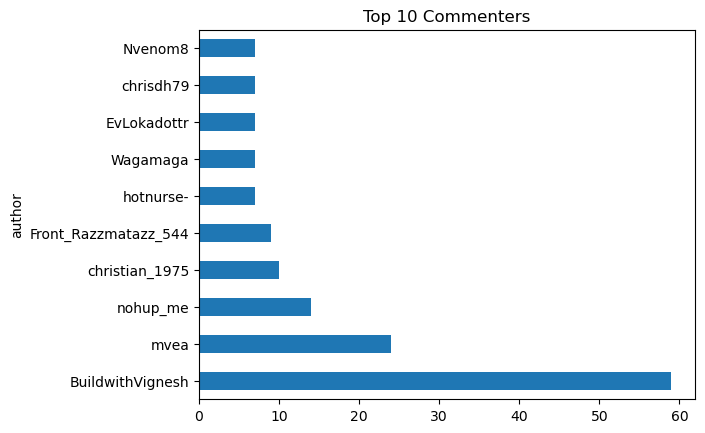

In [76]:
top_commenters.plot(kind='barh', title='Top 10 Commenters')

Most upvoted and downvoted comments

In [77]:
# Top upvoted
df_m_comments.sort_values('score', ascending=False).head(10)

,author,score,text,post_id
1418,Xyrus2000,5828,Censorship is not people boycotting a product....,1o22eyx
358,mangzane,5511,I think this backs up the idea that genes dete...,1o4afve
2376,seaworks,4998,"They smoke more weed, they have less sex, they...",1o0an0u
1806,AlizarinCrimzen,4763,Good thing everyone's landing high paying jobs...,1o1f0r1
1652,jibbyjackjoe,4311,....how did they even come to this hypothesis?...,1o1nyc1
2841,None,3934,[removed],1nzikv9
3263,fsactual,3398,That headline was a wild ride.,1ny5lnl
1986,midnightmoose,2296,This is a false headline - there is no study l...,1o0v9kl
2375,2cunty4you,2229,"The Wine industry would agree with this, NPR h...",1o0an0u
2840,Icy-Swordfish7784,2208,This article was bad science all around. The d...,1nzikv9


In [78]:
# Most downvoted
df_m_comments.sort_values('score', ascending=True).head(10)

,author,score,text,post_id
1581,liquid_at,-92,I've been saying for years that the way the fa...,1o22eyx
1276,Helloprinz,-86,Should not have started a war. Hamas should ha...,1o2ic4c
1274,theBigOne99,-85,Are there actual evidence of malnutrition besi...,1o2ic4c
3475,orbis-restitutor,-81,But reddit told me AI was just hype?,1nxx9j9
3010,None,-73,[removed],1nz9b2n
2320,SeaworthinessNo1920,-70,Still Not more than men I bet.,1o0ipp3
1634,None,-67,[deleted],1o1wnlc
1279,ILuvYou_YouAreSoGood,-66,Having all those kids in what is often describ...,1o2ic4c
196,SalesforceSalesman,-65,Why don't women choose better partners? Are th...,1o4v8nw
3490,DreamLunatik,-53,They are also associated with not eating tasty...,1nxr9pe


In [79]:
controversial = df_m_comments[(df_m_comments["score"] >= -2) & (df_m_comments["score"] <= 2) & (df_m_comments["author"] != "AutoModerator")]
controversial.head(10)

,author,score,text,post_id
1,chrisdh79,1,From the article: People tend to report greate...,1o5psm0
3,nohup_me,1,>The Tsukuba researchers conducted a detailed ...,1o5pn6e
5,cnn,1,The total solar eclipse in North America on Ap...,1o5p4cc
6,That_Kiefer_Man,1,Except that they do that *every* total eclipse.,1o5p4cc
15,Ambitious_Nail3971,1,"I’ll take biased reporting for 100, Alex.",1o5mqea
21,sweetbeard,2,Idk why its so hard for people to grasp that U...,1o5mqea
22,Yung_zu,1,They’re both probably about as close to true p...,1o5mqea
23,Morvack,1,Real science doesn't take political sides.,1o5mqea
24,kfijatass,1,"""More closely"" being the relative term to just...",1o5mqea
25,DartTimeTime,1,"""the party representing 75% of the population ...",1o5mqea


### N-gram visualization

#### bigram

/var/folders/t5/p1xqr73x1slfx2p_g4rrxkrh0000gn/T/ipykernel_17734/2559553689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bigrams.sort_values("count", ascending=False), x="count", y="bigram", palette="mako")


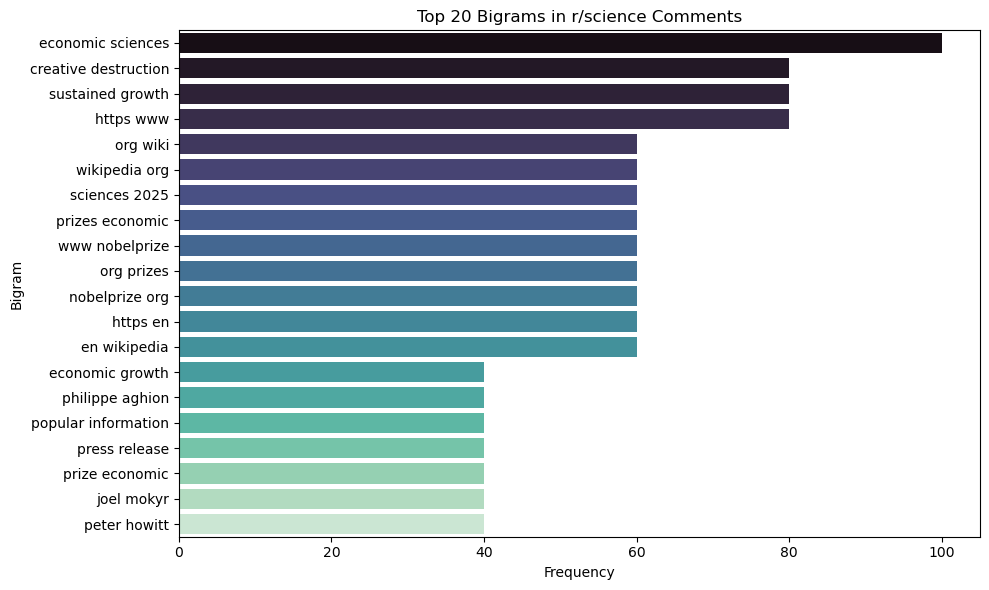

In [80]:
# Clean and vectorize
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english", max_features=20)
X = vectorizer.fit_transform(df_large["text"].dropna())
counts = X.toarray().sum(axis=0)
bigrams = pd.DataFrame({"bigram": vectorizer.get_feature_names_out(), "count": counts})

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=bigrams.sort_values("count", ascending=False), x="count", y="bigram", palette="mako")
plt.title("Top 20 Bigrams in r/science Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()


#### trigram

In [81]:

vectorizer = CountVectorizer(ngram_range=(2,3), stop_words="english", max_features=20)
X = vectorizer.fit_transform(df_large["text"].dropna())
ngrams = vectorizer.get_feature_names_out()
print("Top n-grams:", ngrams)


Top n-grams: ['creative destruction' 'economic sciences' 'economic sciences 2025'
 'en wikipedia' 'en wikipedia org' 'https en' 'https en wikipedia'
 'https www' 'https www nobelprize' 'nobelprize org'
 'nobelprize org prizes' 'org prizes economic' 'org wiki'
 'prizes economic' 'prizes economic sciences' 'sciences 2025'
 'sustained growth' 'wikipedia org' 'www nobelprize' 'www nobelprize org']


/var/folders/t5/p1xqr73x1slfx2p_g4rrxkrh0000gn/T/ipykernel_17734/2241150595.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trigrams.sort_values("count", ascending=False), x="count", y="trigram", palette="mako")


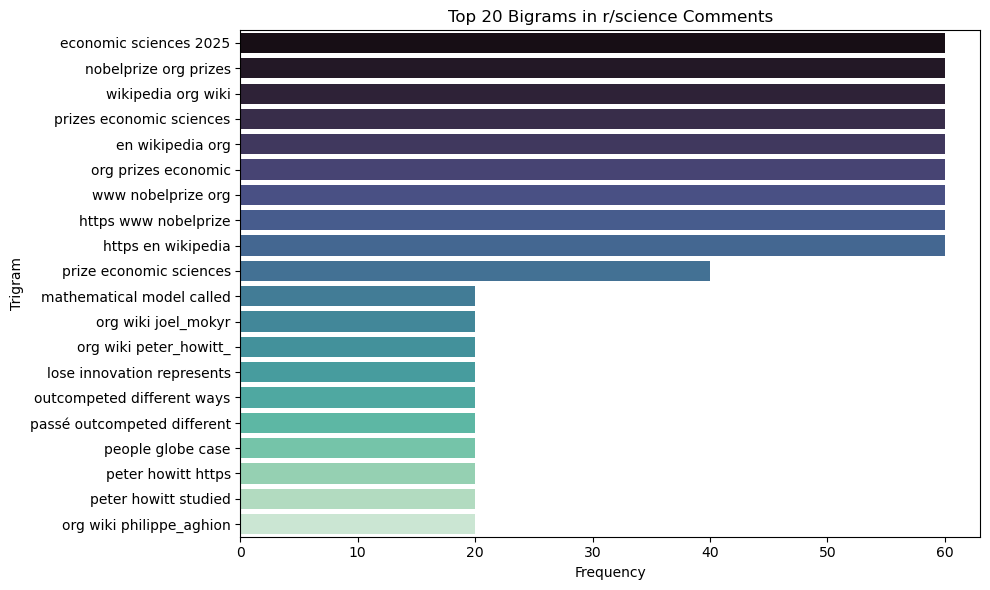

In [82]:
vectorizer = CountVectorizer(ngram_range=(3,3), stop_words="english", max_features=20)
X = vectorizer.fit_transform(df_large["text"].dropna())
counts = X.toarray().sum(axis=0)
trigrams = pd.DataFrame({"trigram": vectorizer.get_feature_names_out(), "count": counts})

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=trigrams.sort_values("count", ascending=False), x="count", y="trigram", palette="mako")
plt.title("Top 20 Bigrams in r/science Comments")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.tight_layout()
plt.show()

### Collocations

In [83]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/ada/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/ada/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/ada/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [84]:
# Combine text from titles and selftext
all_text = ' '.join(df_large['title'].fillna('') + ' ' + df_large['text'].fillna(''))

In [85]:
# Clean the text
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [86]:
cleaned_text = clean_text(all_text)

In [88]:
# Tokenize the text
tokens = word_tokenize(cleaned_text)

In [89]:
# Remove stop words
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]

In [90]:
from nltk.util import ngrams 

# ensure filtered_tokens is a list
tokens = list(filtered_tokens)

bigrams = list(ngrams(tokens, 2))
trigrams = list(ngrams(tokens, 3))


In [91]:
# Count the frequency of n-grams
bigram_counts = Counter(bigrams)
trigram_counts = Counter(trigrams)

In [92]:
print("Most common bigrams:")
display(bigram_counts.most_common(10))

print("\nMost common trigrams:")
display(trigram_counts.most_common(10))

Most common bigrams:


[(('new', 'study'), 200),
 (('study', 'finds'), 120),
 (('sustained', 'growth'), 120),
 (('mental', 'health'), 100),
 (('study', 'found'), 100),
 (('creative', 'destruction'), 100),
 (('prize', 'economic'), 60),
 (('economic', 'sciences'), 60),
 (('social', 'media'), 60),
 (('true', 'people'), 40)]


Most common trigrams:


[(('prize', 'economic', 'sciences'), 60),
 (('new', 'study', 'found'), 40),
 (('sveriges', 'riksbank', 'prize'), 40),
 (('riksbank', 'prize', 'economic'), 40),
 (('economic', 'sciences', 'memory'), 40),
 (('sciences', 'memory', 'alfred'), 40),
 (('memory', 'alfred', 'nobel'), 40),
 (('alfred', 'nobel', '2025'), 40),
 (('nobel', '2025', 'awarded'), 40),
 (('2025', 'awarded', 'joel'), 40)]

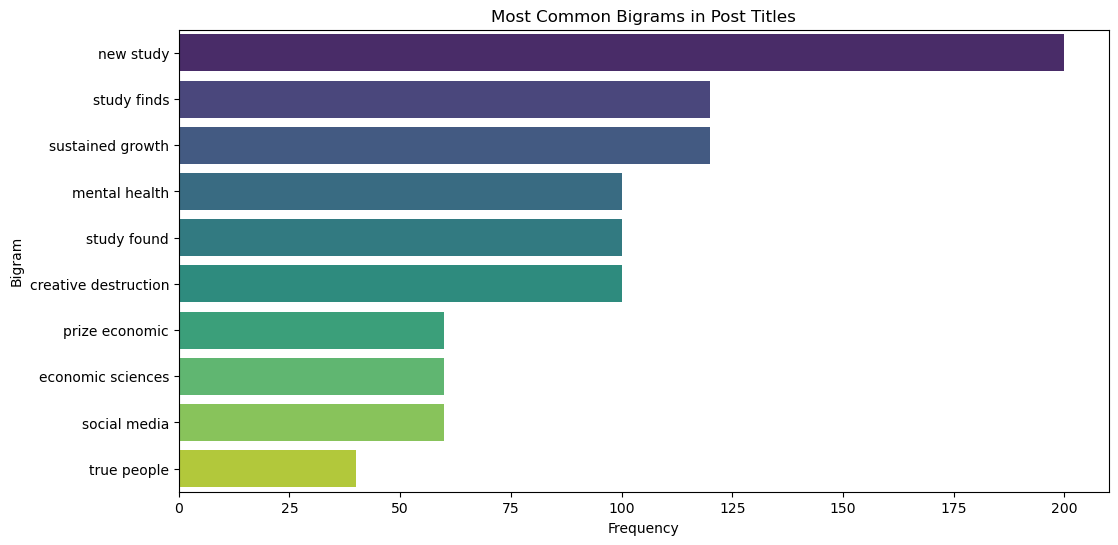

In [93]:
# Visualize the most common bigrams
bigram_df = pd.DataFrame(bigram_counts.most_common(10), columns=['Bigram', 'Frequency'])
bigram_df['Bigram'] = bigram_df['Bigram'].apply(lambda x: ' '.join(x)) # Convert tuples to strings
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Bigram', data=bigram_df, palette='viridis', hue='Bigram', legend=False)
plt.title('Most Common Bigrams in Post Titles')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()

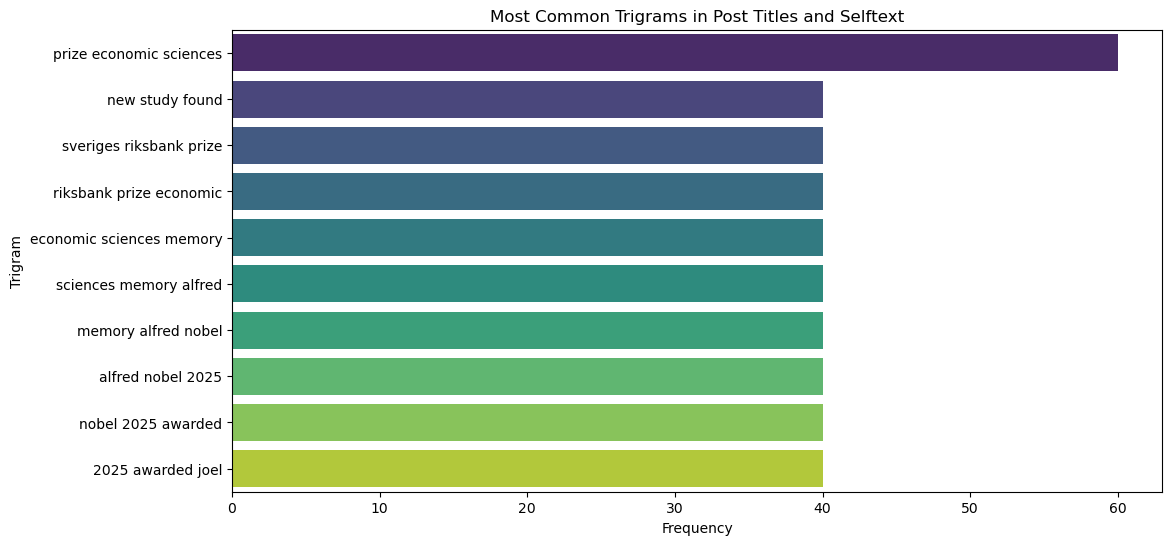

In [94]:
# Visualize the most common trigrams
trigram_df = pd.DataFrame(trigram_counts.most_common(10), columns=['Trigram', 'Frequency'])
trigram_df['Trigram'] = trigram_df['Trigram'].apply(lambda x: ' '.join(x)) # Convert tuples to strings
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Trigram', data=trigram_df, palette='viridis', hue='Trigram', legend=False)
plt.title('Most Common Trigrams in Post Titles and Selftext')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.show()

### Optonal Task Summary

We implemented and tested a custom function to fetch more than 1000 posts from the r/science subreddit by using pagination. This function was further modified to also collect comments associated with each post, enabling a richer dataset for analysis. 

The expanded dataset—containing both posts and comments—was saved to a new SQLite database file named `co_reddit.sqlite`. We then performed exploratory data analysis (EDA) on the comments, identifying top commenters and examining the most upvoted, downvoted, and controversial contributions. 

To deepen the text analysis, we combined post titles and selftext, cleaned and tokenized the text, removed stop words, and generated frequent bigrams and trigrams. These n-grams were visualized to uncover recurring phrases and thematic patterns across the subreddit.

# Analysis

Write a short analysis of the process and results here.

Here is what we learned
- Most posts receive low scores and few comments, but a small number go viral — confirmed by skewed distributions and outliers.
- Log-scaled plots helped reveal structure in comment variability, showing that typical engagement is modest but highly variable.
- A handful of users dominate posting activity.
- Scatter plots revealed a weak but visible correlation between post score and comment count
- NLP on titles and selftext revealed dominant terms like “study,” “found,” “researchers,” and “people,” reflecting the subreddit’s scientific focus.
- Bigrams and trigrams (e.g. “peer reviewed study”, “researchers found”) show recurring phrases that shape the discourse.
- Collocations helped uncover meaningful word pairings that go beyond frequency — useful for topic modeling or summarization.